# 1.前向传播  
> 数据“从左到右”流过神经网络，最终得到预测结果的过程。

1). 准备工作：将输入变量值 (inputs)、权重（weights，如果是首次迭代，则随机初始化）和数据的真实输出 (outputs) 作为 feed_forward 函数的参数：  
    - inputs：输入数据  
    - outputs：真实答案  
    - weights：神经网络的权重，控制着数据如何被处理   
    - pred_out：预测输出
   
2). 通过执行输入层和权重值 (weights[0]) 的矩阵乘法（np.dot）来计算隐藏层值，并将偏置值 (weights[1]) 添加到隐藏层中，利用权重和偏置值就可以将输入层连接到隐藏层  

3).在获得的隐藏层值 (pre_hidden) 之上应用 sigmoid 激活函数  

4).通过对隐藏层激活值 (hidden) 和权重 (weights[2]，将隐藏层连接到输出层)执行矩阵乘法 (np.dot) 计算输出层值，然后在输出上添加偏置项 (weights[3])  

5)计算所有数据样本的均方误差值并返回

In [28]:
import numpy as np
def feed_forward(inputs, outputs, weights):
    pre_hidden = np.dot(inputs, weights[0]) + weights[1]
    hidden = 1/(1+np.exp(-pre_hidden))  #Sigmoid函数
    pred_out = np.dot(hidden, weights[2]) + weights[3]
    mean_squared_error = np.mean(np.square(pred_out - outputs))
    return mean_squared_error

---

# 2.反向传播  
### 2.1反向传播流程  
在前向传播中，我们将输入层连接到隐藏层，然后将隐藏层连接到输出层。在第一次迭代时，随机初始化权重，然后计算网络在当前权重值下的损失。在反向传播中，我们采用相反的方法。利用从前向传播中计算的损失值，并以尽可能最小化损失值为目标更新网络权重，网络权重更新步骤如下：  
1. 每次对神经网络中的每个权重进行少量更改
2. 测量权重变化 ($\delta W$) 时的损失变化 ($\delta L$)
3. 计算 $-k\frac{\delta L}{\delta W}$ 更新权重(其中 $k$ 为学习率，且为正值，是神经网络中重要的超参数)  
>学习率有助于构建更稳定的算法。例如，在确定权重更新的大小时，我们并不会一次性就对其进行大幅度更改，而是采取更谨慎的方法来缓慢地更新权重。这使模型获得更高的稳定性。
  
对特定权重所做的更新与损失值的减少成正比，也就是说，如果改变一个权重可以大幅减少损失，那么权重的更新就会较大，但是，如果改变权重仅能小幅减少损失，那么就只需要小幅度更新权重。 

在整个数据集上执行 n 次上述过程(包括前向传播和反向传播)，表示模型进行了 n 个 epoch 的训练(执行一次称为一个 epoch)。  

由于神经网络通常可能包含数以百万计的权重，因此更改每个权重的值，并检查损失的变化在实践中并不是最佳方法。上述步骤的核心思想是计算权重变化时的“损失变化”，即计算损失值关于权重的梯度。  

接下来，我们将通过一次少量更新一个权重来从零开始实现梯度下降。  
### 2.2梯度下降  
更新权重以减少误差值的整个过程称为梯度下降 (gradient descent)。随机梯度下降 (stochastic gradient descent, SGD) 是将误差最小化的一种方法，其中随机 (stochastic) 表示随机选择数据集中的训练数据样本，并根据该样本做出决策。除了随机梯度下降外，还有许多其他优化器可以用于减少损失值。​接下来，我们将研究如何使用 Python 从零开始实现反向传播，并介绍如何使用链式法则进行反向传播。  
#### 2.2.1实现梯度下降算法  
1.定义前馈网络并计算均方误差损失值：

In [29]:
from copy import deepcopy
import numpy as np
def feef_forward(inputs,outputs,weights):
        pre_hidden = np.dot(inputs, weights[0]) + weights[1]
        hidden = 1/(1+np.exp(-pre_hidden))
        pred_out = np.dot(hidden,weights[2]) + weights[3]
        mean_squared_error = np.mean(np.square(pred_out - outputs))
        return mean_squared_error

2.定义更新权重的函数

In [26]:
def update_weights(inputs, outputs, weights, lr):# lr = 学习率（learning rate），控制调整幅度
    original_weights = deepcopy(weights) #原版
    temp_weights = deepcopy(weights) #试验版
    updated_weights = deepcopy(weights) #最终更新版

3.计算原始损失

In [ ]:
original_loss = feed_forward(inputs, outputs, original_weights)

4.遍历网络所有层

In [ ]:
for i, layer in enumerate(original_weights):
    # i=0: 输入→隐藏层的权重矩阵
    # i=1: 隐藏层的偏置向量
    # i=2: 隐藏→输出层的权重矩阵  
    # i=3: 输出层的偏置值

示例神经网络中包含四个参数列表，前两个列表分别表示将输入连接到隐藏层的权重和偏置项参数，另外两个表示连接隐藏层和输出层的权重和偏置参数。循环遍历所有参数，因为每个参数列表都有不同的形状，因此使用 np.ndenumerate 循环遍历给定列表中的每个参数：

In [ ]:
for index, weight in np.ndenumerate(layer):

5.将原始权重集存储在 temp_weights 中，循环每一参数并为其增加一个较小值，并使用神经网络的新权重集计算新损失：

In [ ]:
temp_weights = deepcopy(weights)
temp_weights[i][index] += 0.0001
_loss_plus = feed_forward(inputs, outputs,temp_weights)

6.计算梯度(损失变化率)  
- 梯度为负 → 增加这个权重能减少损失  
- 梯度为正 → 减少这个权重能减少损失  
- 梯度绝对值大 → 这个权重对损失影响大，要多调

In [ ]:
grad = (_loss_plus - original_loss) /0.0001

7.更新权重，并且使用学习了lr让权重更加稳定：

In [ ]:
updated_weights[i][idex] -= grad * lr

8.所有参数值更新后，返回更新后的权重值——updated_weights：

In [ ]:
return updated_weights, original_loss

- 完整简化代码

In [ ]:
def update_weights_simple(inputs, outputs, weights, lr=0.01):
    """笨方法梯度下降（数值梯度）"""
    original_weights = deepcopy(weights)
    updated_weights = deepcopy(weights)
    
    # 原始损失
    original_loss = feed_forward(inputs, outputs, original_weights)
    
    # 对每个权重做微调测试
    for i in range(len(weights)):  # 遍历4个权重组
        for row in range(weights[i].shape[0]):  # 遍历行
            for col in range(weights[i].shape[1]):  # 遍历列
                
                # 复制原权重
                temp_weights = deepcopy(original_weights)
                
                # 微调这一个权重
                temp_weights[i][row, col] += 0.0001
                
                # 计算新损失
                new_loss = feed_forward(inputs, outputs, temp_weights)
                
                # 计算梯度
                grad = (new_loss - original_loss) / 0.0001
                
                # 更新权重
                updated_weights[i][row, col] -= grad * lr
    
    return updated_weights, original_loss

#### 2.2.2使用链式法则实现反向传播  
我们已经学习了如何通过对权重进行小量更新，然后计算权重更新前后损失的差异来计算与权重有关的损失梯度。当网络参数较多时，以这种方式更新权重值需要进行大量计算来得到损失值，因此需要较大的资源和时间。接下来，我们将学习如何利用链式法则来获取与权重值有关的损失梯度。

![神经网络](../Images/1.png)
网络的损失值表示如下：

$$Loss_{MSE}(C) = (y - \hat{y})^2$$

预测输出值 $\hat{y}$ 计算如下：

$$\hat{y} = a_{11} * w_{31} + a_{12} * w_{32} + a_{13} * w_{33}$$

隐藏层激活值（sigmoid 激活）计算如下：

$$a_{11} = \frac{1}{1 + e^{-h_{11}}}$$

隐藏层值计算如下：

$$h_{11} = x_1 * w_{11} + x_2 * w_{21}$$

计算损失值 $C$ 的变化相对于权重 $w_{11}$ 的变化：

$$\frac{\partial C}{\partial w_{11}} = \frac{\partial C}{\partial \hat{y}} * \frac{\partial \hat{y}}{\partial a_{11}} * \frac{\partial a_{11}}{\partial h_{11}} * \frac{\partial h_{11}}{\partial w_{11}}$$

上式称为链式法则（chain rule），在上式中我们建立了一个偏微分方程链，分别对四个分量执行偏微分，并最终计算损失值相对于权重的导数值 $w_{11}$。上式中的各个偏导数计算如下。

损失值相对于预测输出值 $\hat{y}$ 的偏导数如下：

$$\frac{\partial C}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}}(y - \hat{y})^2 = -2 * (y - \hat{y})$$

预测输出值 $\hat{y}$ 相对于隐藏层激活值 $a_{11}$ 的偏导数如下：

$$\frac{\partial \hat{y}}{\partial a_{11}} = \frac{\partial}{\partial a_{11}}\left(a_{11} * w_{31} + a_{12} * w_{32} + a_{13} * w_{33}\right) = w_{31}$$

隐藏层激活值 $a_{11}$ 相对于隐藏层值 $h_{11}$ 的偏导数如下：

$$\frac{\partial a_{11}}{\partial h_{11}} = a_{11} * (1 - a_{11})$$

隐藏层值 $h_{11}$ 相对于权重值 $w_{11}$ 的偏导数如下：

$$\frac{\partial h_{11}}{\partial w_{11}} = \frac{\partial}{\partial w_{11}}\left(x_1 * w_{11} + x_2 * w_{21}\right) = x_1$$

因此，损失值相对于 $w_{11}$ 的梯度可以表示为：

$$\frac{\partial C}{\partial w_{11}} = -2 * (y - \hat{y}) * w_{31} * a_{11} * (1 - a_{11}) * x_1$$

从上式可以看出，我们现在能够直接计算权重值的微小变化对损失值的影响（损失相对于权重的梯度），而无需重新计算前向传播。接下来，更新权重值：

$$updated\_weight = original\_weight - lr * gradient\_of\_loss$$

---

# 3.合并前向传播和反向传播  
我们将构建一个带有隐藏层(连接输入与输出)的简单神经网络，使用在上一小节中介绍的简单数据集，并利用 update_weights 函数执行反向传播以获得最佳权重和偏置值。模型定义如下：  
1. 输入连接到具有三个神经元(节点)的隐藏层。
2. 隐藏层连接到具有一个神经元的输出层  

1).导入相关库并定义数据集

In [30]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
x = np.array([[1,1]])
y = np.array([[0]])

2).随机初始化权重和偏置值 
 
隐藏层中有三个神经元，每个输入节点都连接到隐藏层神经元。因此，共有六个权重值和三个偏置值，每个隐藏层神经元包含一个偏置和两个权重(每个输入到隐藏层神经元的连接都对应一个权重)；最后一层有一个神经元连接到隐藏层的三个单元，因此包含三个权重和一个偏置值。随机初始化的权重如下：

In [31]:
# 定义权重矩阵列表 W
W = [
    np.array([[-0.0053, 0.3793],
              [-0.5820, -0.5204],
              [-0.2723, 0.1896]], dtype=np.float32).T,
    np.array([-0.0140, 0.5607, -0.0628], dtype=np.float32),
    np.array([[ 0.1528, -0.1745, -0.1135]], dtype=np.float32).T,
    np.array([-0.5516], dtype=np.float32)
]

- 第一个参数数组对应于将输入层连接到隐藏层的 2 x 3 权重矩阵
- 第二个参数数组表示与隐藏层的每个神经元相关的偏置值；  
- 第三个参数数组对应于将隐藏层连接到输出层的 3 x 1 权重矩阵  
- 最后一个参数数组表示与输出层相关的偏置值。  

3).在 100 个 epoch 内执行前向传播和反向传播，使用以上部分中定义的 feed_forward 和 update_weights 函数。

In [32]:
import numpy as np
from copy import deepcopy

def feed_forward(inputs, outputs, weights):    
    # 计算隐藏层前值（线性组合）
    pre_hidden = np.dot(inputs, weights[0]) + weights[1]
    # 隐藏层激活（sigmoid函数）
    hidden = 1 / (1 + np.exp(-pre_hidden))
    # 输出层计算
    out = np.dot(hidden, weights[2]) + weights[3]
    # 计算均方误差（MSE）
    mean_squared_error = np.mean(np.square(out - outputs))
    return mean_squared_error

def update_weights(inputs, outputs, weights, lr):
    original_weights = deepcopy(weights)
    temp_weights = deepcopy(weights)
    updated_weights = deepcopy(weights)
    original_loss = feed_forward(inputs, outputs, original_weights)
    
    # 遍历每一层权重
    for i, layer in enumerate(original_weights):
        # 遍历权重的每个元素（支持任意维度）
        for index, weight in np.ndenumerate(layer):
            temp_weights = deepcopy(original_weights)  # 每次更新前重置为原始权重
            temp_weights[i][index] += 0.0001  # 微小扰动
            _loss_plus = feed_forward(inputs, outputs, temp_weights)
            # 数值法计算梯度（有限差分）
            grad = (_loss_plus - original_loss) / 0.0001
            # 梯度下降更新权重
            updated_weights[i][index] -= grad * lr
    return updated_weights, original_loss

# ------------------- 测试示例（可选） -------------------
if __name__ == "__main__":
    # 1. 定义输入、输出和权重（使用你之前提供的权重）
    inputs = np.array([[0.1, 0.2]], dtype=np.float32)  # 输入样本 (1, 2)
    outputs = np.array([[0.5]], dtype=np.float32)      # 目标输出 (1, 1)
    weights = [
        np.array([[-0.0053, 0.3793],
                  [-0.5820, -0.5204],
                  [-0.2723, 0.1896]], dtype=np.float32).T,
        np.array([-0.0140, 0.5607, -0.0628], dtype=np.float32),
        np.array([[ 0.1528, -0.1745, -0.1135]], dtype=np.float32).T,
        np.array([-0.5516], dtype=np.float32)
    ]
    
    # 2. 测试前向传播
    initial_loss = feed_forward(inputs, outputs, weights)
    print(f"初始损失值: {initial_loss:.6f}")
    
    # 3. 测试权重更新（学习率lr=0.01）
    updated_weights, loss_before_update = update_weights(inputs, outputs, weights, lr=0.01)
    print(f"更新前损失值: {loss_before_update:.6f}")
    print("\n更新后的第一层权重（示例）:")
    print(updated_weights[0])

初始损失值: 1.282634
更新前损失值: 1.282634

更新后的第一层权重（示例）:
[[-0.00521655 -0.58208346 -0.2723477 ]
 [ 0.37949073 -0.5205907   0.18946888]]


4).绘制损失值

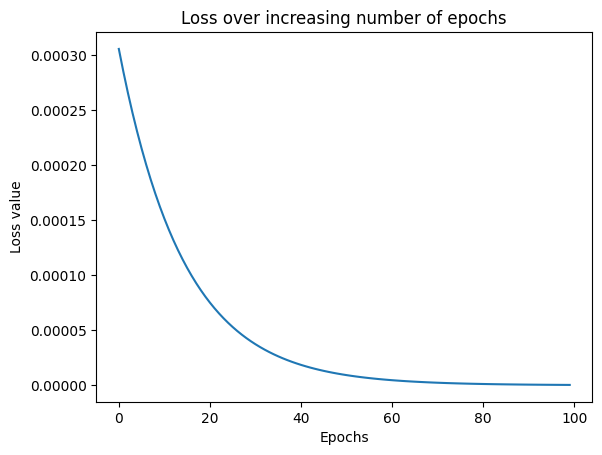

In [34]:
# 初始化损失列表
losses = []
# 100轮训练循环
for epoch in range(100):
    # 更新权重并获取当前轮次的损失值
    W, loss = update_weights(x, y, W, 0.01)
    # 记录每轮损失
    losses.append(loss)

# 绘制损失变化曲线
plt.plot(losses)
plt.title('Loss over increasing number of epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.show()

>损失值最初为 0.33 左右，然后逐渐下降到 0.0001 左右，这表明权重是根据输入-输出数据调整的，当给定输入时，我们可以通过调整网络参数得到预期目标值。

调整后的权重如下：

In [35]:
print(W)

[array([[ 0.01506643, -0.59090847, -0.27539763],
       [ 0.39966387, -0.52930844,  0.18650205]], dtype=float32), array([ 0.00636643,  0.55179155, -0.06589807], dtype=float32), array([[ 0.35342827],
       [-0.05173677],
       [ 0.04213764]], dtype=float32), array([-0.21466923], dtype=float32)]


>使用 NumPy 数组从零开始构建网络虽然不是最佳方法，但可以为理解神经网络的工作原理打下坚实的基础。

5).获取更新的权重后，通过将输入传递给网络对输入进行预测并计算输出值：

In [36]:
pre_hidden = np.dot(x,W[0]) + W[1]
hidden = 1/(1+np.exp(-pre_hidden))
pred_out = np.dot(hidden, W[2]) + W[3]
print(pred_out)

[[-0.00055506]]


结果十分接近于0  

---

# 4.神经网络训练过程总结  
训练神经网络主要通过重复两个关键步骤，即以给定的学习率进行前向传播和反向传播，最终神经网络架构得到最佳权重。

在前向传播中，我们对输入数据应用一组权重，将其传递给定义的隐藏层，对隐藏层的输出执行非线性激活，然后通过将隐藏层节点值与另一组权重相乘来将隐藏层连接到输出层，以估计输出值；最终计算出对应于给定权重集的损失。需要注意的是，第一次前向传播时，权重的值是随机初始化的。 

在反向传播中，通过在损失减少的方向上调整权重来减少损失值(误差)，权重更新的幅度等于梯度乘以学习率。  

重复前向传播和反向传播的过程，直到获得尽可能小的损失，在训练结束时，神经网络已经将其权重 θ \theta θ 调整调整到近似最优值，以便获取期望的输出结果。